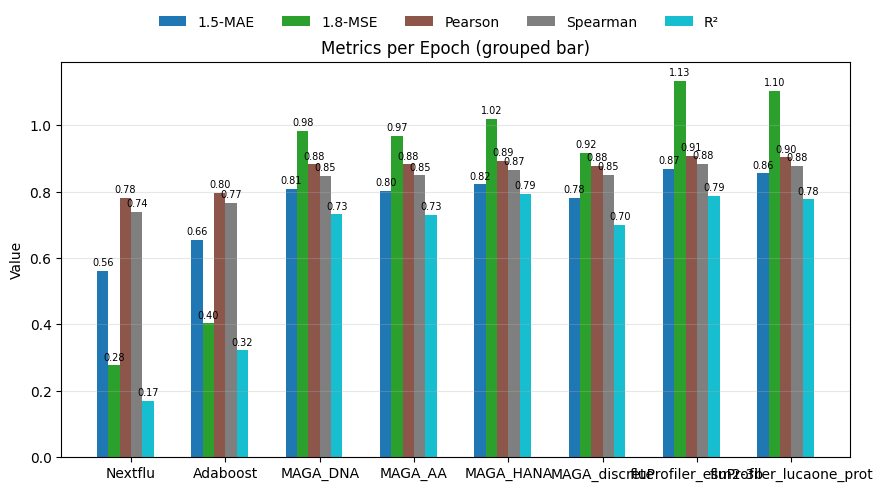

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
labels = ['1.5-MAE','1.8-MSE','Pearson','Spearman','R²']

data = np.array([
    [0.93887, 0.84463, 0.69136, 0.69821, 0.67792, 0.71764, 0.63197, 0.64445],   # MAE
    [1.52321, 1.39689, 0.81565, 0.83127, 0.77943, 0.88178, 0.66504, 0.69524],   # MSE
    [0.78164, 0.79606, 0.88284, 0.88215, 0.89261, 0.87742, 0.90809, 0.90386],   # Pearson
    [0.73878, 0.76661, 0.84715, 0.84949, 0.86518, 0.85082, 0.88314, 0.87789],   # Spearman
    [0.1691 , 0.3216 , 0.73202, 0.72993, 0.79436, 0.70037, 0.78765, 0.77729]    # R2
])  # shape = (5, 6)
data[0,:] = 1.5 - data[0,:]
data[1,:] = 1.8 - data[1,:]


n_metrics, n_epochs = data.shape
x = np.arange(n_epochs)              # 0-5 代表 6 个 Epoch
width = 0.12                         # 每根柱子宽度
colors = plt.cm.tab10(np.linspace(0, 1, n_metrics))

# 画图
fig, ax = plt.subplots(figsize=(9,5))
for i, (label, color) in enumerate(zip(labels, colors)):
    offset = (i - n_metrics/2) * width      # 让柱子横向排开
    bars = ax.bar(x + offset, data[i], width, label=label, color=color)
    # 数值标签（可选）
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height+0.01,
                f'{height:.2f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(['Nextflu', 'Adaboost', 'MAGA_DNA', 'MAGA_AA', 'MAGA_HANA', 'MAGA_discrete', 'fluProfiler_esm2-3b', 'fluProfiler_lucaone_prot'])
ax.set_ylabel('Value')
ax.set_title('Metrics per Epoch (grouped bar)')
ax.legend(bbox_to_anchor=(0.85, 1.15), ncol=5, frameon=False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
# plt.show()
fig.savefig('hi.svg', transparent=True)